In [1]:
# 머신러닝 
# 지도학습 - 정답
    # 분류(Classification), 회귀(Regression)
# 비지도학습 - 정답이없음
    # 클러스터링, 군집
# 강화학습
# 딥러닝 - 신경망

# EDA(탐색적 데이터분석) - 모델 - 추론
    # 데이터 전처리
        # 이상치 제거(대처), 결측치 제거(대처), 새로운 피처생성
        # 상관지수를 통한 적절한 변수 선택
    # 적절한 모델선택
    # 평가
    # 추론

In [2]:
# y = ax + b
# y 정답
# x 입력값
# a 기울기
# b 절편(bias)  보정하기위한 즉 미세조정하는 의미

In [4]:
%conda install scikit-learn

3 channel Terms of Service accepted
Retrieving notices: done
Solving environment: done

## Package Plan ##

  environment location: c:\Users\Playdata\miniconda3\envs\base_stream

  added / updated specs:
    - scikit-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    icc_rt-2022.1.0            |       h6049295_2         6.5 MB
    joblib-1.5.3               |  py314haa95532_0         530 KB
    scikit-learn-1.8.0         |  py314h7b8e219_0         8.5 MB
    scipy-1.17.1               |  py314h4318f7c_0        21.9 MB
    threadpoolctl-3.5.0        |  py314h56ec5ee_1          50 KB
    ------------------------------------------------------------
                                           Total:        37.5 MB

The following NEW packages will be INSTALLED:

  icc_rt             pkgs/main/win-64::icc_rt-2022.1.0-h6049295_2 
  joblib             pkgs/main/win-64::joblib-1.5.3-py314haa9

Error while loading conda entry point: conda-libmamba-solver (DLL load failed while importing bindings: 지정된 모듈을 찾을 수 없습니다.)


==> WARNING: A newer version of conda exists. <==
  current version: 26.1.1
  latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=26.3.1




In [5]:
%conda update -n base -c defaults conda

3 channel Terms of Service accepted

Note: you may need to restart the kernel to use updated packages.


Error while loading conda entry point: conda-libmamba-solver (DLL load failed while importing bindings: 지정된 모듈을 찾을 수 없습니다.)

NoBaseEnvironmentError: This conda installation has no default base environment. Use
'conda create' to create new environments and 'conda activate' to
activate environments.




In [7]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# 데이터 준비
x = np.array([1,2,3,4,5]).reshape(-1,1)  # 공부시간
y = np.array([50,60,65,70,72])
print(x.shape, y.shape)

# 모델생성
model = LinearRegression()
# 모델학습
model.fit(x,y)

# 학습결과
print(f'기울기 : {model.coef_}')
print(f'절편 : {model.intercept_}')

new_x = np.array([5,10,3.5,20]).reshape(-1,1)
print(f'새로운데이터 x에대한 모델이 예측한 값 : {model.predict(new_x)}')

(5, 1) (5,)
기울기 : [5.4]
절편 : 47.199999999999996
새로운데이터 x에대한 모델이 예측한 값 : [ 74.2 101.2  66.1 155.2]


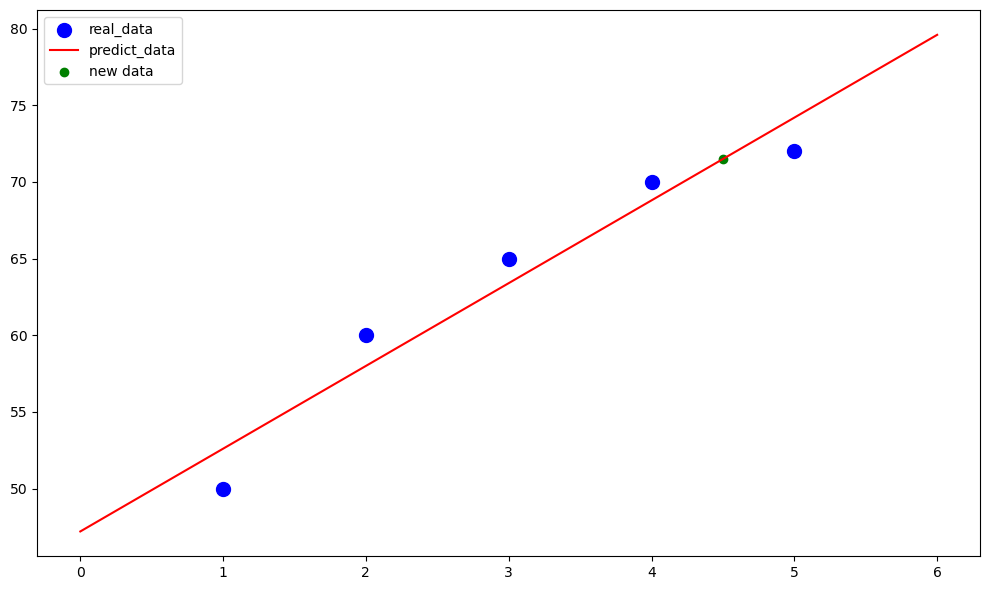

In [21]:
fig, ax  = plt.subplots(figsize=(10,6))
ax.scatter(x,y,color = 'blue',s=100, label='real_data')
# 머신러닝이 예측한 예측직선
x_line = np.linspace(0,6,100).reshape(-1,1)
y_line = model.predict(x_line)
ax.plot(x_line,y_line,color='red',label='predict_data')
# 새로운 예측값
new_x = np.array([[4.5]])
new_y = model.predict(new_x)
ax.scatter(new_x,new_y,color='green',label = 'new data')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# age	나이
# sex	성별
# bmi	체질량지수 (Body Mass Index)
# bp	평균 혈압
# s1	총 혈청 콜레스테롤
# s2	저밀도 지단백 (LDL)
# s3	고밀도 지단백 (HDL)
# s4	총 콜레스테롤 / HDL 비율
# s5	혈청 중성지방의 로그값
# s6	혈당 수치
# 모든 컬럼은 평균 0, 표준편차 1로 정규화(standardized) 되어 있음

In [49]:
df.head(1)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.05068,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0


In [51]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
df = load_diabetes(as_frame=True).frame
df.head()
x = df[['bmi']]
y = df['target']
print(x.shape, y.shape)

# y = ax + b
# 1 모델 선택
model = LinearRegression()
# 2. 모델 학습
model.fit(x,y)
# 3. 모델 예측(추론)
predicted = model.predict(np.array([[0.061696]]) )
print(predicted)


(442, 1) (442,)
[210.70984199]


c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [194]:
import random
random_index = random.sample(range(442),442)  # 0 ~ 441  섞음
x2 =  x['bmi'][random_index]
y2 =  y[random_index]

split_count = int(len(x['bmi'])*0.8)

x2_train = x2[:split_count]
y2_train = y2[:split_count]

x2_test = x2[split_count : ]
y2_test = y2[split_count : ]

model = LinearRegression()

model.fit(x2_train.to_numpy().reshape(-1,1),y2_train)  # 모델 학습

# 예측
predicted =  model.predict(x2_test.to_numpy().reshape(-1,1))

from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
mean_absolute_error(y2_test,predicted), mean_squared_error(y2_test,predicted), r2_score(y2_test,predicted)

(47.5854618406059, 3194.1163182118726, 0.35845693718025673)

In [ ]:
# 데이터 (X, Y)
# 데이터를 섞어서 분할(학습용과 테스트용)
# 적절한 모델 선택
# 학습->학습용 데이터
# 추론(예측) ->테스트용 데이터
# 평가 : 테스트용데이터의 실제 정답 vs 모델이 테스트용 데이터로 예측한값의 오차

In [198]:
# train_test_split
from sklearn.model_selection import train_test_split
X = df[['bmi',	'bp']].to_numpy().reshape(-1,2)
y = df['target'].to_numpy()
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=55)
print(x_train.shape, x_test.shape)
model = LinearRegression()
# 학습
model.fit(x_train,y_train)
# 예측
predicted = model.predict(x_test)
# 평가
mean_absolute_error(y_test,predicted), mean_squared_error(y_test, predicted), r2_score(y_test,predicted)

(353, 2) (89, 2)


(49.83247252337205, 3645.206910287863, 0.3476726738553554)

In [224]:
y = np.array([1,2,3,4])

y_hat = np.array([1,2,3,4.1])

# 평균
y_mean = y.mean()
# SS_tot : 데이터 자체의 변동성  데이터의 퍼짐정도
SS_tot = sum((y - y_mean)**2)

#SS_res  모델 오차
SS_res = sum((y - y_hat)**2)  # 모델이 틀린 총량  0.18

#R2_score (결정계수)  1- SSres/SStot

print(f'결정계수 : {1-  SS_res/SS_tot}')
print(f'전체변동 : {SS_tot}')
print(f'모델이 못 맞춘부분 : {SS_res}')
print(f'모델이 설명한 부분 : {SS_tot-SS_res}')

결정계수 : 0.998
전체변동 : 5.0
모델이 못 맞춘부분 : 0.009999999999999929
모델이 설명한 부분 : 4.99


In [226]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# 데이터, 데이터 분리(훈련데이터,평가데이터), 학습(훈련데이터)  평가(평가용데이터) --> 평가함수를통해 성능을 지표로 표현
# 1 데이터로드 
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
# 2개의 변수 선택
feature_cols = ['bmi','bp']
x = df[feature_cols]
y = df['target']
# 2 데이터 분리
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=40)
# 3 파이프라인구성  (전처리(스케일링) 과 선형회귀를 묶어)
pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),('model', LinearRegression())
])
pipeline.fit(x_train,y_train)
y_pred = pipeline.predict(x_test)
print(r2_score(y_test,y_pred)  )

0.31709000017431


In [227]:
# 선형회귀 LinearRegression
# 데이터분할 train_test_split
# 모델평가 지표(결정계수, 평균제곱오차, 평균절대값오차)

In [247]:
# 오리지널
df = sns.load_dataset('diamonds')
df.head()
# carat depth table 학습해서 price 예측하는 모델 개발
x = df[['carat','depth','table']]
y = df['price']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=15)
model = LinearRegression()
model.fit(x_train,y_train)
y_predict = model.predict(x_test)

mse = mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

mse, mae, r2

(2381131.8368172497, 997.378481605238, 0.8513761360965127)

In [248]:
scaler = StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)  # 규칙을 적용하고 적용한 규칙기반으로 데이터를 변환
x_test_scaled = scaler.transform(x_test)
model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_scaled_predict = model.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_scaled_predict)
mae = mean_absolute_error(y_test, y_scaled_predict)
r2 = r2_score(y_test, y_scaled_predict)

mse, mae, r2

(2381131.83681725, 997.3784816052366, 0.8513761360965127)

In [243]:
x.corr()

,carat,depth,table
carat,1.000000,0.028224,0.181618
depth,0.028224,1.000000,-0.295779
table,0.181618,-0.295779,1.000000


In [254]:
from lightgbm import LGBMRegressor
# 파이프라인적용
############### 1 데이터 로드 및 분할 #########################
df = sns.load_dataset('diamonds')
x = df[['carat','depth','table']]
y = df['price']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=15)
###########  2파이프라인 설계 ################
pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('model',LGBMRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=7,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1,
        )
     )
])
###########  3파이프라인 실행 ################
pipeline.fit(x_train,y_train)
y_predict = pipeline.predict(x_test)
###########  4평가 ################
print(mean_squared_error(y_test, y_predict), mean_absolute_error(y_test,y_predict), r2_score(y_test,y_predict))

print(pipeline.score(x_test,y_test))

1928312.3199251506 812.1055647794896 0.8796399160396556
0.8796399160396556


c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
